In [1]:
# Install dependencies
%pip install pandas numpy matplotlib seaborn fredapi scipy --progress-bar on

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
#  CEE Government Bond Yield Correlation Analysis
#  Hermann Ossani — Quantitative Finance, WU Vienna
#
#  Countries : Poland, Czech Rep., Hungary, Slovakia,
#              Austria, Bulgaria, Croatia, Romania + Germany
#
#  Data source : FRED (St. Louis Fed) — free, requires API key
#  Library     : fredapi (pip install fredapi)
#  Methodology : Correlation of monthly yield changes (bps)
#
#  Free FRED API key (30 seconds):
#  https://fred.stlouisfed.org/docs/api/api_key.html
# ============================================================

# ── CELL 1 — IMPORTS ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns           # Statistical data visualization library built on Matplotlib
from fredapi import Fred

print("All libraries imported successfully")

All libraries imported successfully


In [5]:
# ── CELL 2 — CONNECT TO FRED ────────────────────────────────
# Get your free API key at:
# https://fred.stlouisfed.org/docs/api/api_key.html

FRED_API_KEY = "779ebed3d62c58406e3855f082a47187"
fred = Fred(api_key=FRED_API_KEY)
print("Connected to FRED")

Connected to FRED


In [6]:
# ── CELL 3 — FRED SERIES KEYS ───────────────────────────────
# Source: OECD via FRED — monthly, 10-year government bond yields
# Series format: IRLTLT01{CC}M156N
# where CC = 2-letter country code
#
# Country codes:
#   AT=Austria  BG=Bulgaria  CZ=Czech Rep.  HR=Croatia
#   HU=Hungary  PL=Poland    RO=Romania     SK=Slovakia
#   DE=Germany (benchmark)

SERIES = {
    "Germany":    "IRLTLT01DEM156N",   # European benchmark
    "Austria":    "IRLTLT01ATM156N",
    "Poland":     "IRLTLT01PLM156N",
    "Czech Rep.": "IRLTLT01CZM156N",
    "Hungary":    "IRLTLT01HUM156N",
    "Slovakia":   "IRLTLT01SKM156N",
    "Bulgaria":   "IRLTLT01BGM156N",
    "Croatia":    "IRLTLT01HRM156N",
    "Romania":    "IRLTLT01ROM156N",
}

In [7]:
# ── CELL 4 — FETCH DATA FROM FRED ───────────────────────────
print("Fetching data from FRED...\n")

raw = {}
for country, series_id in SERIES.items():
    try:
        s = fred.get_series(series_id, observation_start="2005-01-01")
        raw[country] = s
        n = s.notna().sum()
        print(f"  ✓  {country:<14} {n} months of data")
    except Exception as e:
        print(f"  ✗  {country:<14} Could not load — {e}")

Fetching data from FRED...

  ✓  Germany        253 months of data
  ✓  Austria        254 months of data
  ✓  Poland         254 months of data
  ✓  Czech Rep.     254 months of data
  ✓  Hungary        254 months of data
  ✓  Slovakia       254 months of data
  ✗  Bulgaria       Could not load — Bad Request.  The series does not exist.
  ✗  Croatia        Could not load — Bad Request.  The series does not exist.
  ✗  Romania        Could not load — Bad Request.  The series does not exist.


In [8]:
# ── CELL 5 — CLEAN & ALIGN DATA ─────────────────────────────
df = pd.DataFrame(raw).sort_index()

print("Data coverage per country (non-null months):")
print(df.notna().sum())

df_clean = df.dropna()

print(f"\nClean dataset : {len(df_clean)} months")
print(f"Period        : {df_clean.index[0].strftime('%B %Y')} — "
      f"{df_clean.index[-1].strftime('%B %Y')}")

Data coverage per country (non-null months):
Germany       253
Austria       254
Poland        254
Czech Rep.    254
Hungary       254
Slovakia      254
dtype: int64

Clean dataset : 253 months
Period        : January 2005 — January 2026


In [9]:
# ── CELL 6 — YIELD CHANGES & CORRELATION ────────────────────
# Correlations computed on monthly yield CHANGES (basis points)
# not levels — levels are non-stationary and give misleading results
# 1 basis point = 0.01 percentage point

df_changes = df_clean.diff().dropna() * 100
corr = df_changes.corr()

print("Correlation matrix (monthly yield changes):")
print(corr.round(2))

Correlation matrix (monthly yield changes):
            Germany  Austria  Poland  Czech Rep.  Hungary  Slovakia
Germany        1.00     0.89    0.54        0.59     0.32      0.55
Austria        0.89     1.00    0.58        0.68     0.48      0.59
Poland         0.54     0.58    1.00        0.75     0.64      0.50
Czech Rep.     0.59     0.68    0.75        1.00     0.59      0.52
Hungary        0.32     0.48    0.64        0.59     1.00      0.40
Slovakia       0.55     0.59    0.50        0.52     0.40      1.00


In [10]:
# ── CELL 7 — COLOUR PALETTE ─────────────────────────────────
COLORS = {
    "Germany":    "#888888",
    "Austria":    "#264653",
    "Poland":     "#E63946",
    "Czech Rep.": "#457B9D",
    "Hungary":    "#2A9D8F",
    "Slovakia":   "#E9C46A",
    "Bulgaria":   "#F4A261",
    "Croatia":    "#A8DADC",
    "Romania":    "#6A0572",
}

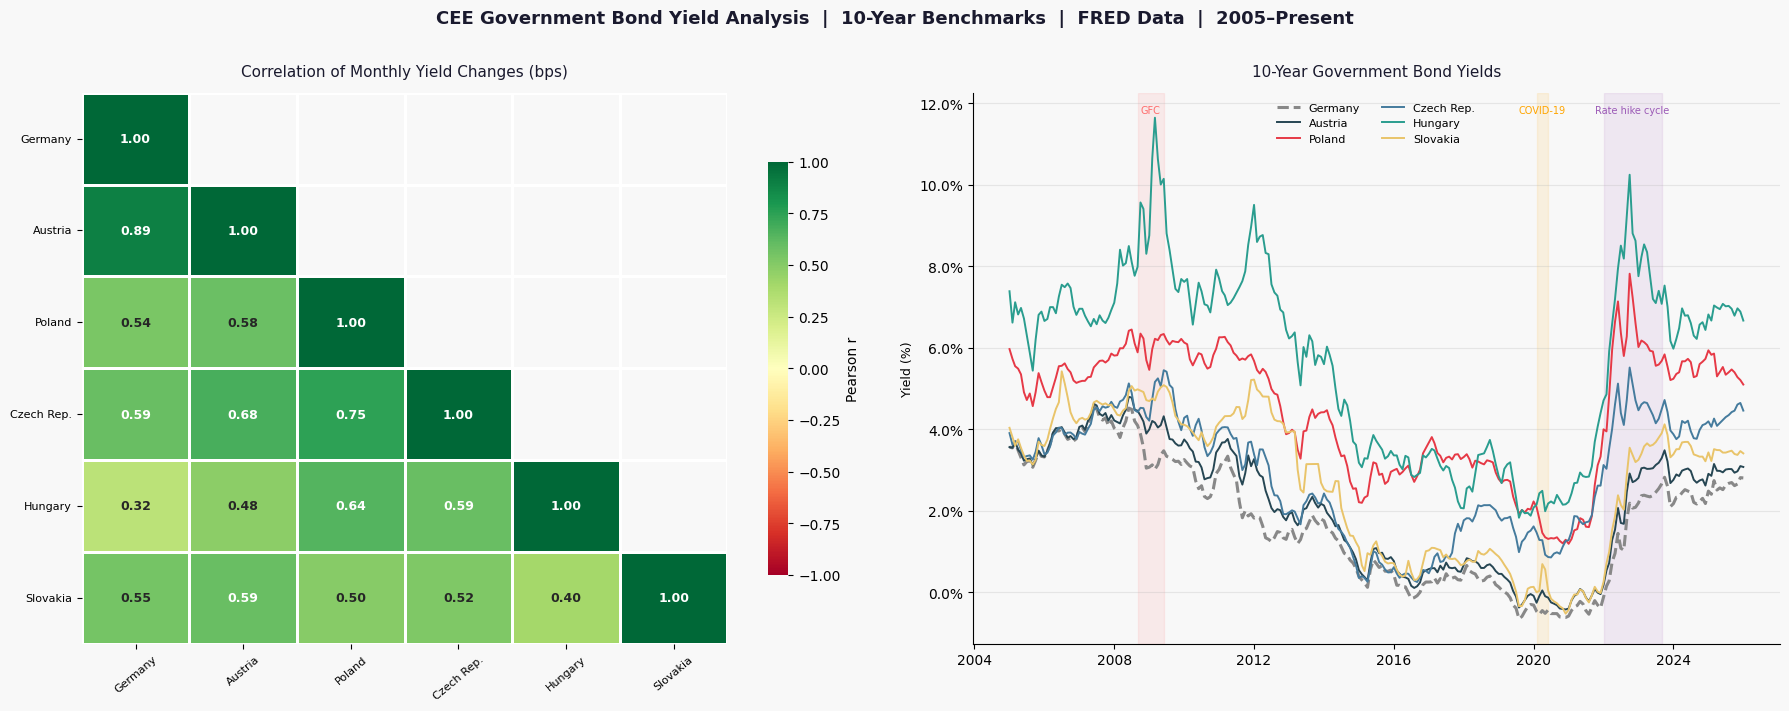

✓ Saved: cee_bond_heatmap_fred.png


In [11]:
# ── CELL 8 — FIGURE 1: HEATMAP + TIME SERIES ────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#F8F8F8")
for ax in axes:
    ax.set_facecolor("#F8F8F8")

fig.suptitle(
    "CEE Government Bond Yield Analysis  |  10-Year Benchmarks  |  FRED Data  |  2005–Present",
    fontsize=13, fontweight="bold", y=1.01, color="#1A1A2E"
)

# Heatmap — lower triangle only
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, ax=axes[0], mask=mask,
    annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=-1, vmax=1,
    linewidths=0.8, linecolor="white",
    annot_kws={"size": 9, "weight": "bold"},
    cbar_kws={"label": "Pearson r", "shrink": 0.75}
)
axes[0].set_title("Correlation of Monthly Yield Changes (bps)",
                  fontsize=11, pad=12, color="#1A1A2E")
axes[0].tick_params(axis="x", rotation=40, labelsize=8)
axes[0].tick_params(axis="y", rotation=0,  labelsize=8)

# Time series
for col in df_clean.columns:
    lw = 2.2 if col == "Germany" else 1.4
    ls = "--" if col == "Germany" else "-"
    axes[1].plot(df_clean.index, df_clean[col],
                 label=col, color=COLORS[col],
                 linewidth=lw, linestyle=ls)

# Shade macro events
events = [
    ("2008-09-01", "2009-06-01", "#FF6B6B", "GFC"),
    ("2020-02-01", "2020-06-01", "#FFA500", "COVID-19"),
    ("2022-01-01", "2023-09-01", "#9B59B6", "Rate hike cycle"),
]
for start, end, color, label in events:
    axes[1].axvspan(start, end, alpha=0.10, color=color)
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    axes[1].text(mid, axes[1].get_ylim()[1] * 0.96,
                 label, fontsize=7, color=color, ha="center")

axes[1].set_title("10-Year Government Bond Yields",
                  fontsize=11, pad=12, color="#1A1A2E")
axes[1].set_ylabel("Yield (%)", fontsize=9)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
axes[1].legend(frameon=False, fontsize=8, ncol=2)
axes[1].grid(axis="y", alpha=0.25)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("cee_bond_heatmap_fred.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("✓ Saved: cee_bond_heatmap_fred.png")

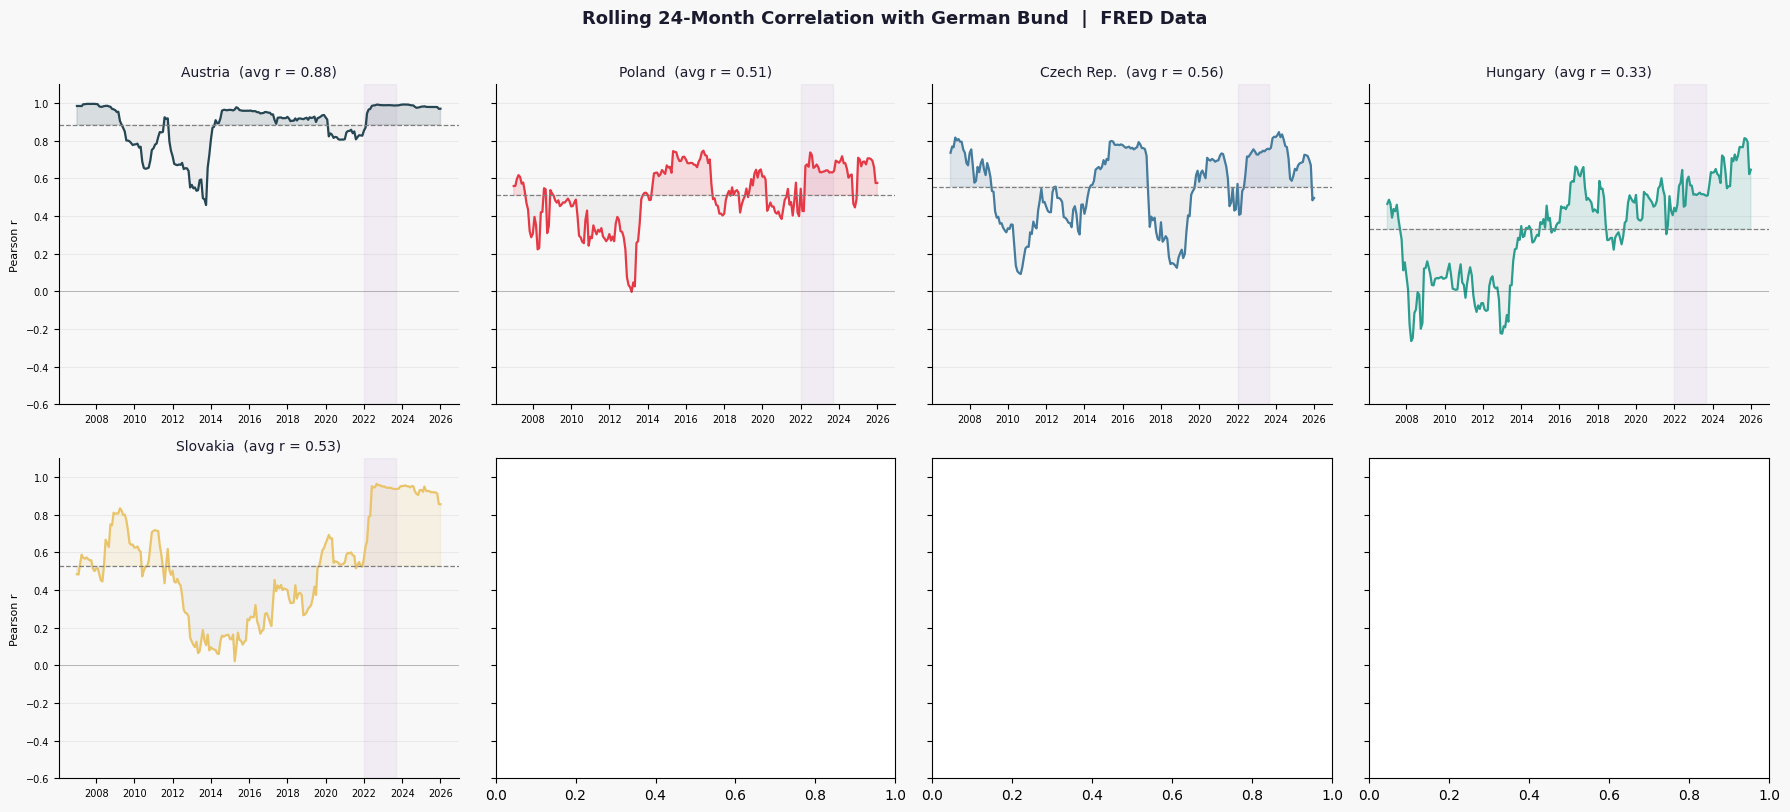

✓ Saved: cee_rolling_correlation_fred.png


In [12]:
# ── CELL 9 — FIGURE 2: ROLLING CORRELATIONS VS GERMANY ──────
# Shows how much each CEE country co-moves with the German benchmark
# Rising line = convergence with Europe. Falling = divergence.
cee_only = [c for c in df_clean.columns if c != "Germany"]

fig2, axes2 = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
fig2.patch.set_facecolor("#F8F8F8")
fig2.suptitle(
    "Rolling 24-Month Correlation with German Bund  |  FRED Data",
    fontsize=13, fontweight="bold", y=1.01, color="#1A1A2E"
)

for i, country in enumerate(cee_only):
    ax = axes2.flatten()[i]
    ax.set_facecolor("#F8F8F8")
    color = COLORS[country]

    rolling = (df_changes[country]
               .rolling(24)
               .corr(df_changes["Germany"])
               .dropna())
    mean_r = rolling.mean()

    ax.plot(rolling.index, rolling, color=color, linewidth=1.6)
    ax.axhline(mean_r, color="gray", linestyle="--", linewidth=0.9)
    ax.fill_between(rolling.index, rolling, mean_r,
                    where=(rolling >= mean_r), alpha=0.15, color=color)
    ax.fill_between(rolling.index, rolling, mean_r,
                    where=(rolling <  mean_r), alpha=0.08, color="gray")
    ax.axvspan("2022-01-01", "2023-09-01", alpha=0.07, color="#9B59B6")

    ax.set_title(f"{country}  (avg r = {mean_r:.2f})",
                 fontsize=10, color="#1A1A2E", pad=6)
    ax.set_ylim(-0.6, 1.1)
    ax.axhline(0, color="black", linewidth=0.5, alpha=0.3)
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=7)
    ax.set_ylabel("Pearson r" if i % 4 == 0 else "", fontsize=8)

plt.tight_layout()
plt.savefig("cee_rolling_correlation_fred.png", dpi=150,
            bbox_inches="tight", facecolor=fig2.get_facecolor())
plt.show()
print("✓ Saved: cee_rolling_correlation_fred.png")

In [13]:
# ── CELL 10 — SUMMARY STATISTICS ────────────────────────────
print("\n" + "=" * 60)
print("KEY FINDINGS  —  FRED Data")
print("=" * 60)
print(f"\n{'Country':<14} {'Avg Yield':>10} {'Std Dev':>10} {'Corr vs DE':>12}")
print("-" * 50)
for country in cee_only:
    avg  = df_clean[country].mean()
    std  = df_clean[country].std()
    r_de = corr.loc[country, "Germany"]
    print(f"{country:<14} {avg:>9.2f}%  {std:>9.2f}%  {r_de:>11.3f}")

print("\nTop 5 strongest correlated pairs:")
pairs = []
for i in range(len(cee_only)):
    for j in range(i + 1, len(cee_only)):
        a, b = cee_only[i], cee_only[j]
        pairs.append((a, b, corr.loc[a, b]))
pairs.sort(key=lambda x: x[2], reverse=True)
for a, b, r in pairs[:5]:
    print(f"  {a} ↔ {b:<14}  r = {r:.3f}")

print("\nBottom 3 weakest correlated pairs:")
for a, b, r in pairs[-3:]:
    print(f"  {a} ↔ {b:<14}  r = {r:.3f}")

print("\nData source: FRED — Federal Reserve Bank of St. Louis")
print("Series: OECD Harmonised Long-Term Interest Rates")
print("=" * 60)


KEY FINDINGS  —  FRED Data

Country         Avg Yield    Std Dev   Corr vs DE
--------------------------------------------------
Austria             2.15%       1.53%        0.891
Poland              4.45%       1.55%        0.538
Czech Rep.          2.90%       1.49%        0.587
Hungary             5.73%       2.27%        0.318
Slovakia            2.67%       1.75%        0.552

Top 5 strongest correlated pairs:
  Poland ↔ Czech Rep.      r = 0.747
  Austria ↔ Czech Rep.      r = 0.675
  Poland ↔ Hungary         r = 0.641
  Austria ↔ Slovakia        r = 0.593
  Czech Rep. ↔ Hungary         r = 0.590

Bottom 3 weakest correlated pairs:
  Poland ↔ Slovakia        r = 0.498
  Austria ↔ Hungary         r = 0.482
  Hungary ↔ Slovakia        r = 0.404

Data source: FRED — Federal Reserve Bank of St. Louis
Series: OECD Harmonised Long-Term Interest Rates
